In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rkiattisak/salaly-prediction-for-beginer")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/rkiattisak/salaly-prediction-for-beginer


In [7]:
import os
df = pd.read_csv(os.path.join(path, "Salary Data.csv"))

print(df.head())
print(df.info())

    Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary

In [8]:
print(df.isnull().sum())

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64


In [9]:
df.fillna(df.mean(numeric_only= True), inplace=True)

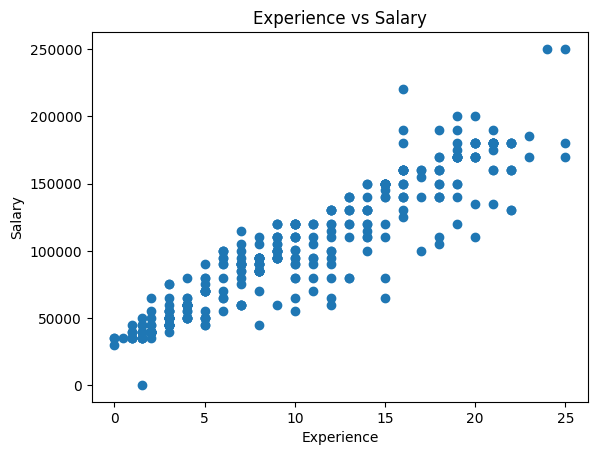

In [10]:
# Data Visualization
plt.scatter(df['Years of Experience'], df['Salary'])
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Experience vs Salary")
plt.show()

In [11]:
#Define Features
x = df[["Years of Experience"]]
y = df["Salary"]

In [12]:
#Split Data
#80% training and 20% testing
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
#Train Model
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [14]:
#Make Predictions
y_predict = model.predict(x_test)
y_predict

array([154355.22616873,  99726.43447057, 140698.02824419,  72412.03862149,
       147526.62720646, 174841.02305554, 181669.62201781,  99726.43447057,
        51926.24173467,  92897.8355083 , 120212.23135738, 174841.02305554,
        45097.6427724 ,  92897.8355083 ,  58754.84069694, 140698.02824419,
        65583.43965921,  41683.34329127,  79240.63758376,  86069.23654603,
        99726.43447057,  92897.8355083 , 140698.02824419,  65583.43965921,
        99726.43447057,  58754.84069694, 168012.42409327,  99936.96768254,
       154355.22616873, 161183.825131  ,  51926.24173467, 127040.83031965,
        51926.24173467, 133869.42928192,  79240.63758376,  34854.744329  ,
       174841.02305554,  45097.6427724 ,  45097.6427724 ,  58754.84069694,
        45097.6427724 ,  86069.23654603, 202155.41890462, 161183.825131  ,
        45097.6427724 , 140698.02824419, 106555.03343284,  45097.6427724 ,
        45097.6427724 ,  45097.6427724 ,  99726.43447057,  86069.23654603,
        86069.23654603, 1

In [15]:
#Evaluate Model
mae = mean_absolute_error(y_test,y_predict)
print("Mae: ",mae)

Mae:  12279.659887588627


In [16]:
#Predict New Salary
experience = [[5]]
salary= model.predict(experience)
print("Predict Salary: ",salary[0])

Predict Salary:  65583.43965921458


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [17]:
import pickle
pickle.dump(model,open("salary_model.pkl", "wb"))

In [18]:
#import streamlit as st
#import pickle

#model = pickle.load(open("salary_model.pkl", "rb"))

#st.title("Salary Prediction System")

#exp = st.number_input("Years of Experience")

#if st.button("Predict"):
 #   result = model.predict([[exp]])
 #   st.success(f"Predicted Salary: {result[0]:.2f}")